<a href="https://colab.research.google.com/github/ehdrb1023/GraduationProject/blob/main/Muon_SAM_CIFAR_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import os, urllib.request

drive.mount('/content/drive')

drive_data_path = '/content/drive/MyDrive/Colab_Data'
os.makedirs(drive_data_path, exist_ok=True)

cifar_url = 'https://s3.amazonaws.com/fast-ai-imageclas/cifar10.tgz'
destination_path = os.path.join(drive_data_path, 'cifar10.tgz')

if not os.path.exists(destination_path):
    print("🚀 CIFAR-10 다운로드 중...")
    urllib.request.urlretrieve(cifar_url, destination_path)
    print(f"✅ 완료: {os.path.getsize(destination_path)/(1024*1024):.2f} MB")
else:
    print("✨ 이미 존재함")

Mounted at /content/drive
✨ 이미 존재함


In [ ]:
import time, tarfile, torch
import torch.nn as nn, torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Device: {device}")
if torch.cuda.is_available():
    print(f"🖥️ GPU: {torch.cuda.get_device_name(0)}")
print(f"🧵 CPU cores: {os.cpu_count()}\n")

drive_zip_path = '/content/drive/MyDrive/Colab_Data/cifar10.tgz'
local_data_path = '/content/cifar10'

if not os.path.exists(local_data_path):
    print("📦 로컬 압축 해제 중...")
    with tarfile.open(drive_zip_path, 'r:gz') as tar:
        tar.extractall(path='/content/')
    print("✅ 완료\n")
else:
    print("✨ 이미 압축 해제됨\n")

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

train_dataset = datasets.ImageFolder(root=os.path.join(local_data_path, 'train'), transform=transform_train)
test_dataset = datasets.ImageFolder(root=os.path.join(local_data_path, 'test'), transform=transform_test)

NUM_WORKERS = min(os.cpu_count(), 4)  # Colab 무료 티어면 보통 2

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

print(f"📊 Train: {len(train_dataset)} | Test: {len(test_dataset)} | num_workers={NUM_WORKERS}\n")

🖥️ Device: cuda
🖥️ GPU: Tesla T4
🧵 CPU cores: 2

📦 로컬 압축 해제 중...


/tmp/ipykernel_1563/579433883.py:18: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path='/content/')


✅ 완료

📊 Train: 50000 | Test: 10000 | num_workers=2



In [ ]:
def build_model():
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(m.fc.in_features, 10)
    return m.to(device)

print("✅ 모델 빌더 정의 완료")

✅ 모델 빌더 정의 완료


In [ ]:
@torch.no_grad()
def zeropower_via_newtonschulz5(G, steps=5, eps=1e-7):
    assert len(G.shape) == 2
    a, b, c = (3.4445, -4.7750, 2.0315)
    X = G.bfloat16()
    X /= (X.norm() + eps)
    if G.size(0) > G.size(1):
        X = X.T
    for _ in range(steps):
        A = X @ X.T
        B = b * A + c * A @ A
        X = a * X + B @ X
    if G.size(0) > G.size(1):
        X = X.T
    return X.to(G.dtype)

class Muon(optim.Optimizer):
    def __init__(self, params, lr=0.02, momentum=0.95, nesterov=True, ns_steps=5):
        defaults = dict(lr=lr, momentum=momentum, nesterov=nesterov, ns_steps=ns_steps)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()
        for group in self.param_groups:
            for p in group['params']:
                g = p.grad
                if g is None:
                    continue
                state = self.state[p]
                if 'momentum_buffer' not in state:
                    state['momentum_buffer'] = torch.zeros_like(g)
                buf = state['momentum_buffer']
                original_shape = g.shape
                if g.ndim > 2:
                    g = g.view(g.size(0), -1)
                g_ortho = zeropower_via_newtonschulz5(g, steps=group['ns_steps']).view(original_shape)
                buf.mul_(group['momentum']).add_(g_ortho)
                g_update = g_ortho + group['momentum'] * buf if group['nesterov'] else buf
                p.add_(g_update, alpha=-group['lr'])
        return loss

print("✅ Muon 정의 완료")

✅ Muon 정의 완료


In [ ]:
import pandas as pd

def make_log_row(run_name, epoch, phase, train_loss, train_acc, test_acc, epoch_time,
                  sharpness=None, grad_norm=None, lr=None, rho=None):
    return dict(run_name=run_name, epoch=epoch, phase=phase,
                train_loss=train_loss, train_acc=train_acc, test_acc=test_acc,
                sharpness=sharpness, grad_norm=grad_norm, lr=lr, rho=rho,
                epoch_time=epoch_time)

def measure_sharpness(model, criterion, data_loader, device, rho=0.05, n_batches=3):
    """여러 배치 평균으로 노이즈 완화한 SAM 기반 Sharpness 측정"""
    model.eval()
    diffs = []
    it = iter(data_loader)
    for _ in range(n_batches):
        inputs, targets = next(it)
        inputs, targets = inputs.to(device), targets.to(device)
        with torch.no_grad():
            loss_w = criterion(model(inputs), targets).item()
        model.zero_grad()
        criterion(model(inputs), targets).backward()
        grad_norm = torch.norm(torch.stack([
            p.grad.norm(p=2) for p in model.parameters() if p.grad is not None]))
        scale = rho / (grad_norm + 1e-12)
        e_ws = []
        with torch.no_grad():
            for p in model.parameters():
                if p.grad is None: continue
                e_w = p.grad * scale
                p.add_(e_w); e_ws.append((p, e_w))
        with torch.no_grad():
            loss_w_eps = criterion(model(inputs), targets).item()
            for p, e_w in e_ws: p.sub_(e_w)
        model.zero_grad()
        diffs.append(loss_w_eps - loss_w)
    model.train()
    return sum(diffs) / len(diffs)

def measure_grad_norm(model, criterion, inputs, targets):
    """진단용: 현재 배치 기준 전체 파라미터 gradient norm"""
    model.zero_grad()
    criterion(model(inputs), targets).backward()
    gn = torch.norm(torch.stack([
        p.grad.norm(p=2) for p in model.parameters() if p.grad is not None])).item()
    model.zero_grad()
    return gn

print("✅ 로깅 + 측정 함수 정의 완료")

✅ 로깅 + 측정 함수 정의 완료


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

@torch.no_grad()
def get_filter_normalized_direction(model):
    """Li et al. 2018 방식: 필터(파라미터 텐서) 단위로 방향 벡터 크기를 원본 파라미터에 맞춰 정규화"""
    direction = []
    for p in model.parameters():
        d = torch.randn_like(p)
        if p.dim() > 1:
            d_flat = d.view(d.size(0), -1)
            p_flat = p.view(p.size(0), -1)
            d_norm = d_flat.norm(dim=1, keepdim=True)
            p_norm = p_flat.norm(dim=1, keepdim=True)
            d_flat.mul_(p_norm / (d_norm + 1e-10))
        else:
            d.mul_(p.norm() / (d.norm() + 1e-10))
        direction.append(d)
    return direction

def compute_loss_landscape(model, criterion, data_loader, device, n_points=15, span=1.0, n_batches=3):
    """모델 주변 2D 슬라이스로 loss 지형을 계산 (계산량 있으니 최종 모델에 대해서만 1~2회 실행 권장)"""
    model.eval()
    params_backup = [p.clone() for p in model.parameters()]
    d1 = get_filter_normalized_direction(model)
    d2 = get_filter_normalized_direction(model)

    batches = []
    it = iter(data_loader)
    for _ in range(n_batches):
        inputs, targets = next(it)
        batches.append((inputs.to(device), targets.to(device)))

    alphas = np.linspace(-span, span, n_points)
    betas = np.linspace(-span, span, n_points)
    loss_grid = np.zeros((n_points, n_points))

    total = n_points * n_points
    count = 0
    for i, a in enumerate(alphas):
        for j, b in enumerate(betas):
            with torch.no_grad():
                for p, p0, dd1, dd2 in zip(model.parameters(), params_backup, d1, d2):
                    p.copy_(p0 + a * dd1 + b * dd2)
                total_loss = sum(criterion(model(x), y).item() for x, y in batches) / len(batches)
            loss_grid[j, i] = total_loss
            count += 1
            if count % 50 == 0:
                print(f"  ...{count}/{total} 지점 계산 완료")

    with torch.no_grad():
        for p, p0 in zip(model.parameters(), params_backup):
            p.copy_(p0)
    model.train()
    return alphas, betas, loss_grid

def plot_loss_landscape(alphas, betas, loss_grid, title="Loss Landscape", save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    A, B = np.meshgrid(alphas, betas)
    cs = axes[0].contourf(A, B, loss_grid, levels=30, cmap='viridis')
    axes[0].contour(A, B, loss_grid, levels=10, colors='white', linewidths=0.5, alpha=0.5)
    axes[0].plot(0, 0, 'r*', markersize=15, label='현재 모델 위치')
    axes[0].set_xlabel('방향 1'); axes[0].set_ylabel('방향 2')
    axes[0].set_title(f'{title} (등고선)')
    axes[0].legend()
    fig.colorbar(cs, ax=axes[0])

    ax3d = fig.add_subplot(1, 2, 2, projection='3d')
    ax3d.plot_surface(A, B, loss_grid, cmap='viridis', alpha=0.9)
    ax3d.set_xlabel('방향 1'); ax3d.set_ylabel('방향 2'); ax3d.set_zlabel('Loss')
    ax3d.set_title(f'{title} (3D)')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ 저장: {save_path}")
    plt.show()

print("✅ 손실 지형 시각화 함수 정의 완료")

✅ 손실 지형 시각화 함수 정의 완료


In [ ]:
import collections

class DynamicSwitchController:
    def __init__(self, coarse_loss_threshold=0.5, coarse_window=3, coarse_std_threshold=0.03,
                 fine_window=3, fine_change_threshold=0.18, ema_alpha=0.3):
        self.phase = 1
        self.ema_alpha = ema_alpha
        self.loss_ema = None
        self.loss_window = collections.deque(maxlen=coarse_window)
        self.coarse_loss_threshold = coarse_loss_threshold
        self.coarse_std_threshold = coarse_std_threshold
        self.sharpness_window = collections.deque(maxlen=fine_window)
        self.fine_change_threshold = fine_change_threshold

    def update_coarse(self, epoch_train_loss):
        self.loss_ema = epoch_train_loss if self.loss_ema is None \
            else self.ema_alpha * epoch_train_loss + (1 - self.ema_alpha) * self.loss_ema
        self.loss_window.append(epoch_train_loss)
        if self.phase == 1 and len(self.loss_window) == self.loss_window.maxlen:
            loss_std = torch.tensor(list(self.loss_window)).std().item()
            if self.loss_ema <= self.coarse_loss_threshold and loss_std <= self.coarse_std_threshold:
                self.phase = 2
                print(f"\n🔍 [Phase 1→2] Loss EMA={self.loss_ema:.4f}, std={loss_std:.4f} → 센서 가동\n")
        return self.phase

    def update_fine(self, sharpness):
        self.sharpness_window.append(sharpness)
        if self.phase == 2 and len(self.sharpness_window) == self.sharpness_window.maxlen:
            vals = list(self.sharpness_window)
            spread = max(vals) - min(vals)
            if spread <= self.fine_change_threshold:
                self.phase = 3
                print(f"\n🎯 [Phase 2→3] Sharpness 안정화 {[f'{v:.4f}' for v in vals]} → SAM 전환\n")
        return self.phase

print("✅ 트리거 컨트롤러 정의 완료")

✅ 트리거 컨트롤러 정의 완료


In [ ]:
model = build_model()
muon_params, adamw_params = [], []
for name, param in model.named_parameters():
    (muon_params if param.ndim >= 2 else adamw_params).append(param)

optimizer_muon = Muon(muon_params, lr=0.02, momentum=0.95)
optimizer_adamw = optim.AdamW(adamw_params, lr=3e-4, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

RUN_NAME_A = "muon_only_50ep"
epochs = 50
logs_A = []

print(f"🚀 실험 A 시작: {RUN_NAME_A}\n")
for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    start_time = time.time()
    grad_norm_sample = None

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer_muon.zero_grad(); optimizer_adamw.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()

        if batch_idx == 0:
            grad_norm_sample = torch.norm(torch.stack([
                p.grad.norm(p=2) for p in model.parameters() if p.grad is not None])).item()

        optimizer_muon.step(); optimizer_adamw.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    model.eval()
    t_correct, t_total = 0, 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            t_total += targets.size(0)
            t_correct += predicted.eq(targets).sum().item()

    epoch_time = time.time() - start_time
    train_loss = running_loss / len(train_loader)
    train_acc = 100. * correct / total
    test_acc = 100. * t_correct / t_total

    logs_A.append(make_log_row(RUN_NAME_A, epoch+1, 1, train_loss, train_acc, test_acc,
                                epoch_time, sharpness=None, grad_norm=grad_norm_sample, lr=0.02, rho=None))

    print(f"[Muon] Epoch [{epoch+1}/{epochs}] | Time: {epoch_time:.1f}s | "
          f"Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

print("\n🎉 실험 A 종료!")
model_A = model  # 나중에 손실 지형 시각화용으로 보관
df_A = pd.DataFrame(logs_A)

🚀 실험 A 시작: muon_only_50ep

[Muon] Epoch [1/50] | Time: 51.1s | Loss: 1.4478 | Train Acc: 51.98% | Test Acc: 64.93%
[Muon] Epoch [2/50] | Time: 48.6s | Loss: 1.0507 | Train Acc: 67.11% | Test Acc: 70.73%
[Muon] Epoch [3/50] | Time: 47.0s | Loss: 0.9073 | Train Acc: 71.91% | Test Acc: 75.58%
[Muon] Epoch [4/50] | Time: 48.0s | Loss: 0.8281 | Train Acc: 74.79% | Test Acc: 74.15%
[Muon] Epoch [5/50] | Time: 48.4s | Loss: 0.8026 | Train Acc: 76.47% | Test Acc: 77.43%
[Muon] Epoch [6/50] | Time: 50.4s | Loss: 0.7376 | Train Acc: 78.15% | Test Acc: 79.22%
[Muon] Epoch [7/50] | Time: 48.9s | Loss: 0.6918 | Train Acc: 79.22% | Test Acc: 78.90%
[Muon] Epoch [8/50] | Time: 50.0s | Loss: 0.6605 | Train Acc: 80.34% | Test Acc: 79.71%
[Muon] Epoch [9/50] | Time: 51.5s | Loss: 0.6405 | Train Acc: 80.92% | Test Acc: 81.61%
[Muon] Epoch [10/50] | Time: 49.9s | Loss: 0.6399 | Train Acc: 81.54% | Test Acc: 80.99%
[Muon] Epoch [11/50] | Time: 51.2s | Loss: 0.6058 | Train Acc: 82.25% | Test Acc: 82.05%
[Mu

In [ ]:
model = build_model()
muon_params, adamw_params = [], []
for name, param in model.named_parameters():
    (muon_params if param.ndim >= 2 else adamw_params).append(param)

# Phase 1~3 내내 재생성하지 않음 (momentum buffer 연속성 핵심)
optimizer_muon = Muon(muon_params, lr=0.02, momentum=0.95)
optimizer_adamw = optim.AdamW(adamw_params, lr=3e-4, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

controller = DynamicSwitchController(
    coarse_loss_threshold=0.5, coarse_window=3, coarse_std_threshold=0.03,
    fine_window=3, fine_change_threshold=0.18,
)

SENSOR_RHO = 0.05    # Phase 2 센서 측정용
PHASE3_RHO = 0.03    # Phase 3 실제 Ascent용
GRAD_CLIP_NORM = 3.0

RUN_NAME_B = "muon_native_sam_v3"
epochs = 50
logs_B = []

print(f"🚀 실험 B 시작: {RUN_NAME_B}\n")
for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    start_time = time.time()
    phase = controller.phase
    sharpness_val = None
    grad_norm_sample = None

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)

        if phase in (1, 2):
            optimizer_muon.zero_grad(); optimizer_adamw.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()

            if batch_idx == 0:
                grad_norm_sample = torch.norm(torch.stack([
                    p.grad.norm(p=2) for p in model.parameters() if p.grad is not None])).item()

            optimizer_muon.step(); optimizer_adamw.step()

            if phase == 2 and sharpness_val is None:
                sharpness_val = measure_sharpness(model, criterion, train_loader, device,
                                                   rho=SENSOR_RHO, n_batches=3)
        else:
            # Phase 3: Ascent(수동) + Descent(기존 Muon/AdamW 재사용)
            optimizer_muon.zero_grad(); optimizer_adamw.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()

            if batch_idx == 0:
                grad_norm_sample = torch.norm(torch.stack([
                    p.grad.norm(p=2) for p in model.parameters() if p.grad is not None])).item()

            with torch.no_grad():
                gn = torch.norm(torch.stack([
                    p.grad.norm(p=2) for p in model.parameters() if p.grad is not None]))
                scale = PHASE3_RHO / (gn + 1e-12)
                e_ws = []
                for p in model.parameters():
                    if p.grad is None: continue
                    e_w = p.grad * scale
                    p.add_(e_w); e_ws.append((p, e_w))

            optimizer_muon.zero_grad(); optimizer_adamw.zero_grad()
            loss = criterion(model(inputs), targets)
            loss.backward()

            with torch.no_grad():
                for p, e_w in e_ws: p.sub_(e_w)

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
            optimizer_muon.step(); optimizer_adamw.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    model.eval()
    t_correct, t_total = 0, 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            t_total += targets.size(0)
            t_correct += predicted.eq(targets).sum().item()

    epoch_time = time.time() - start_time
    train_loss = running_loss / len(train_loader)
    train_acc = 100. * correct / total
    test_acc = 100. * t_correct / t_total

    controller.update_coarse(train_loss)
    if phase == 2 and sharpness_val is not None:
        controller.update_fine(sharpness_val)

    current_rho = PHASE3_RHO if phase == 3 else (SENSOR_RHO if phase == 2 else None)
    logs_B.append(make_log_row(RUN_NAME_B, epoch+1, phase, train_loss, train_acc, test_acc,
                                epoch_time, sharpness=sharpness_val, grad_norm=grad_norm_sample,
                                lr=0.02, rho=current_rho))

    phase_tag = {1: "P1-Muon", 2: "P2-Sensor", 3: "P3-SAM"}[phase]
    sharp_str = f" | Sharp: {sharpness_val:.4f}" if sharpness_val is not None else ""
    print(f"[{phase_tag}] Epoch [{epoch+1}/{epochs}] | Time: {epoch_time:.1f}s | "
          f"Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%{sharp_str}")

print("\n🎉 실험 B 종료!")
model_B = model
df_B = pd.DataFrame(logs_B)

🚀 실험 B 시작: muon_native_sam_v3

[P1-Muon] Epoch [1/50] | Time: 51.6s | Loss: 1.4550 | Train Acc: 51.35% | Test Acc: 64.54%
[P1-Muon] Epoch [2/50] | Time: 52.7s | Loss: 1.0045 | Train Acc: 67.18% | Test Acc: 71.71%
[P1-Muon] Epoch [3/50] | Time: 51.6s | Loss: 0.8710 | Train Acc: 72.20% | Test Acc: 72.98%
[P1-Muon] Epoch [4/50] | Time: 51.4s | Loss: 0.8042 | Train Acc: 74.73% | Test Acc: 76.94%
[P1-Muon] Epoch [5/50] | Time: 52.1s | Loss: 0.7175 | Train Acc: 77.13% | Test Acc: 77.57%
[P1-Muon] Epoch [6/50] | Time: 51.2s | Loss: 0.6994 | Train Acc: 78.05% | Test Acc: 78.13%
[P1-Muon] Epoch [7/50] | Time: 52.2s | Loss: 0.6715 | Train Acc: 79.05% | Test Acc: 79.58%
[P1-Muon] Epoch [8/50] | Time: 50.7s | Loss: 0.6370 | Train Acc: 80.31% | Test Acc: 80.01%
[P1-Muon] Epoch [9/50] | Time: 52.5s | Loss: 0.6384 | Train Acc: 81.21% | Test Acc: 80.41%
[P1-Muon] Epoch [10/50] | Time: 51.7s | Loss: 0.5677 | Train Acc: 81.90% | Test Acc: 81.01%
[P1-Muon] Epoch [11/50] | Time: 52.6s | Loss: 0.5727 | Tra

In [ ]:
from datetime import datetime

save_dir = '/content/drive/MyDrive/Colab_Data/hybrid_experiments'
os.makedirs(save_dir, exist_ok=True)
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# CSV 저장 (두 실행 합쳐서 하나의 파일로 — 나중에 비교 그래프용)
df_all = pd.concat([df_A, df_B], ignore_index=True)
csv_path = os.path.join(save_dir, f'runs_{timestamp}.csv')
df_all.to_csv(csv_path, index=False)
print(f"✅ CSV 저장: {csv_path}")

# 모델 저장
torch.save(model_A.state_dict(), os.path.join(save_dir, f'{RUN_NAME_A}_{timestamp}.pt'))
torch.save(model_B.state_dict(), os.path.join(save_dir, f'{RUN_NAME_B}_{timestamp}.pt'))
print("✅ 모델 저장 완료")

/tmp/ipykernel_1563/868224514.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat([df_A, df_B], ignore_index=True)


✅ CSV 저장: /content/drive/MyDrive/Colab_Data/hybrid_experiments/runs_20260717_191338.csv
✅ 모델 저장 완료


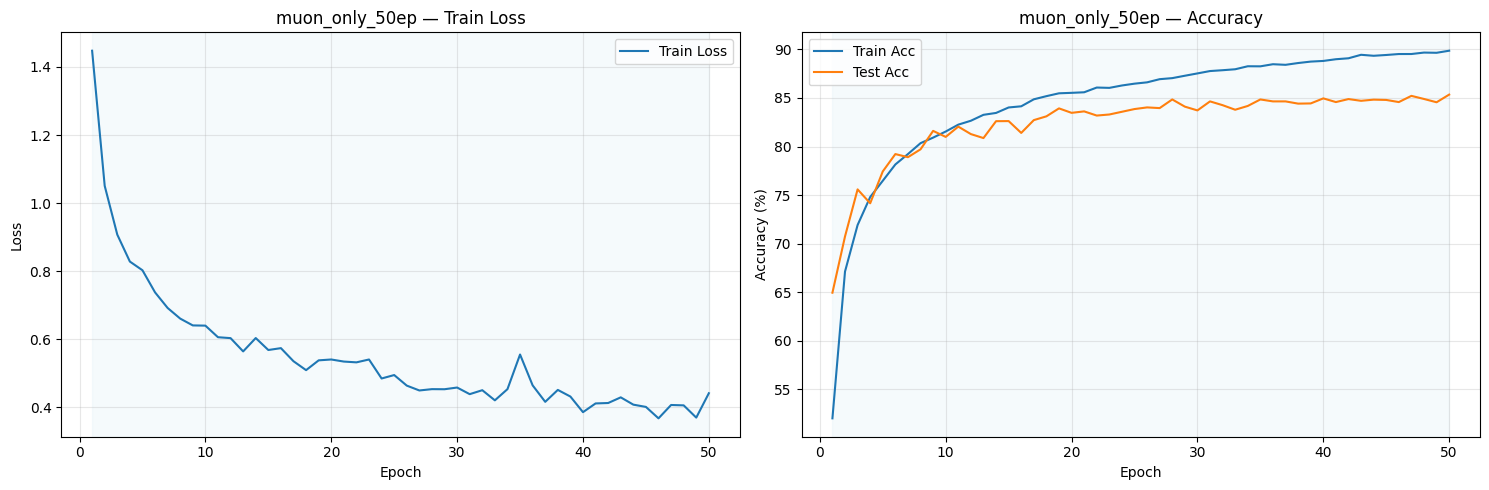

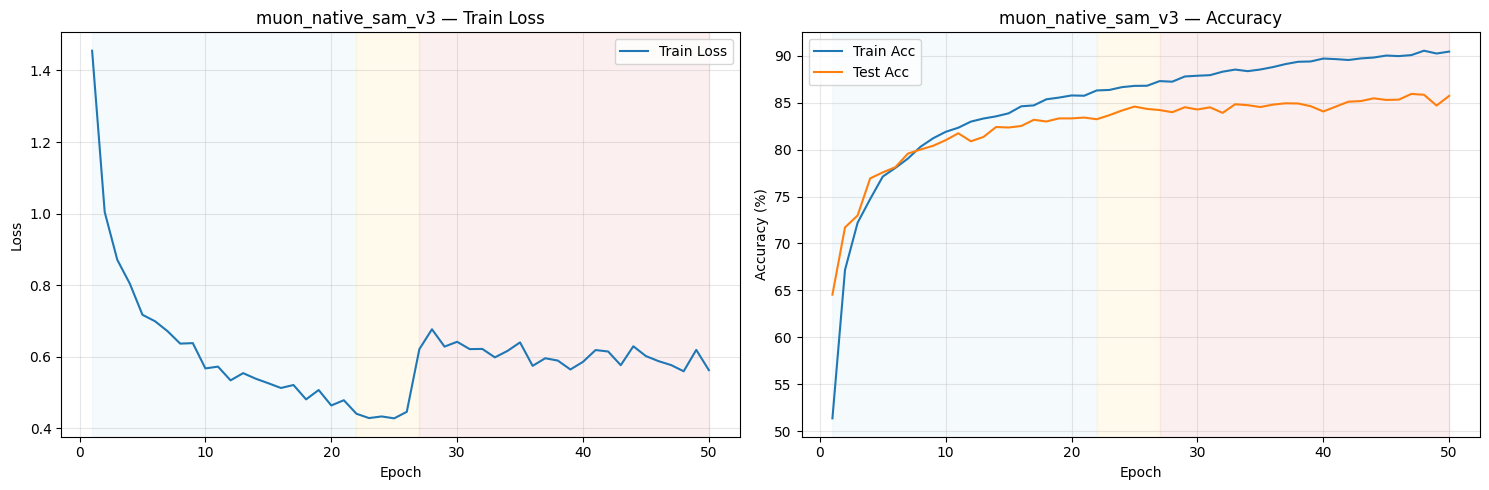

In [ ]:
def plot_training_curves(df, run_name, save_path=None):
    d = df[df['run_name'] == run_name]
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    phase_colors = {1: '#e8f4f8', 2: '#fff3cd', 3: '#f8d7da'}
    for ax in axes:
        prev_phase = d['phase'].iloc[0]
        start_ep = d['epoch'].iloc[0]
        for i in range(1, len(d)+1):
            cur_phase = d['phase'].iloc[i-1] if i <= len(d) else prev_phase
            if i == len(d) or cur_phase != prev_phase:
                end_ep = d['epoch'].iloc[i-1]
                ax.axvspan(start_ep, end_ep, color=phase_colors.get(prev_phase, 'white'), alpha=0.4)
                start_ep = end_ep
                prev_phase = cur_phase

    axes[0].plot(d['epoch'], d['train_loss'], label='Train Loss', color='tab:blue')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{run_name} — Train Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(d['epoch'], d['train_acc'], label='Train Acc', color='tab:blue')
    axes[1].plot(d['epoch'], d['test_acc'], label='Test Acc', color='tab:orange')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title(f'{run_name} — Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_training_curves(df_all, RUN_NAME_A, save_path=os.path.join(save_dir, f'{RUN_NAME_A}_curves.png'))
plot_training_curves(df_all, RUN_NAME_B, save_path=os.path.join(save_dir, f'{RUN_NAME_B}_curves.png'))

/tmp/ipykernel_1563/1839338441.py:16: UserWarning: Glyph 54253 (\N{HANGUL SYLLABLE POG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/1839338441.py:16: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/1839338441.py:16: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/1839338441.py:16: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/1839338441.py:16: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/1839338441.py:17: UserWarning: Glyph 54253 (\N{HANGUL SYLLABLE POG}) missing from font(s) DejaVu Sans.
  if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
/tmp/ipykernel_1563/1839338441.py:17: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) m

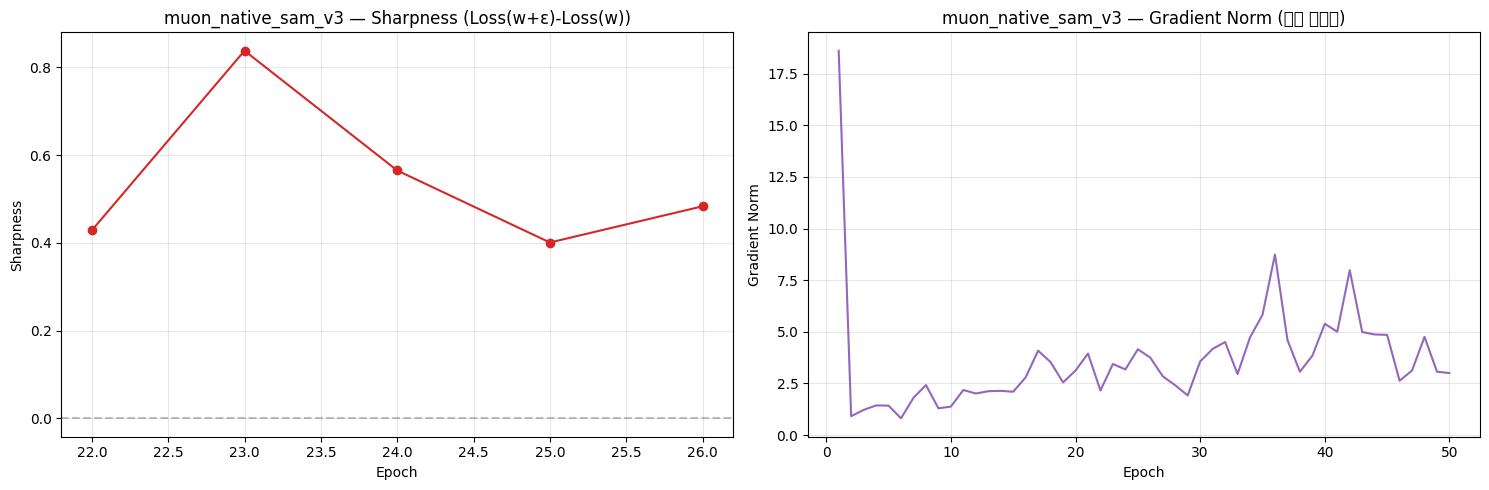

In [ ]:
def plot_sharpness_and_gradnorm(df, run_name, save_path=None):
    d = df[df['run_name'] == run_name]
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    d_sharp = d.dropna(subset=['sharpness'])
    axes[0].plot(d_sharp['epoch'], d_sharp['sharpness'], marker='o', color='tab:red')
    axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Sharpness')
    axes[0].set_title(f'{run_name} — Sharpness (Loss(w+ε)-Loss(w))'); axes[0].grid(alpha=0.3)

    d_gn = d.dropna(subset=['grad_norm'])
    axes[1].plot(d_gn['epoch'], d_gn['grad_norm'], color='tab:purple')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Gradient Norm')
    axes[1].set_title(f'{run_name} — Gradient Norm (폭주 감지용)'); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_sharpness_and_gradnorm(df_all, RUN_NAME_B, save_path=os.path.join(save_dir, f'{RUN_NAME_B}_sharpness.png'))

/tmp/ipykernel_1563/3486515108.py:11: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/3486515108.py:11: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/3486515108.py:11: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/3486515108.py:11: UserWarning: Glyph 44077 (\N{HANGUL SYLLABLE GAEB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/3486515108.py:11: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/3486515108.py:11: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/3486515108.py:11: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from font(s) DejaVu Sans.
  plt.tight_la

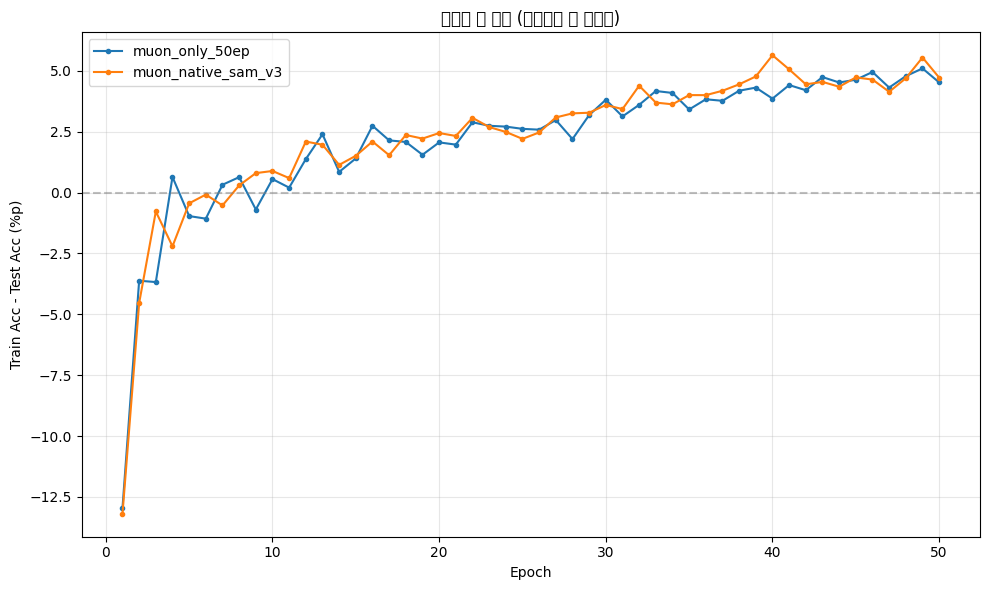

In [ ]:
def plot_generalization_gap(df, run_names, save_path=None):
    fig, ax = plt.subplots(figsize=(10, 6))
    for name in run_names:
        d = df[df['run_name'] == name]
        gap = d['train_acc'] - d['test_acc']
        ax.plot(d['epoch'], gap, label=name, marker='.')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Train Acc - Test Acc (%p)')
    ax.set_title('일반화 갭 비교 (낮을수록 잘 일반화)')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_generalization_gap(df_all, [RUN_NAME_A, RUN_NAME_B],
                         save_path=os.path.join(save_dir, 'generalization_gap.png'))

/tmp/ipykernel_1563/3786517213.py:18: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/3786517213.py:18: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/3786517213.py:18: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/3786517213.py:18: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/3786517213.py:18: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/3786517213.py:18: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/3786517213.py:19: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  if save_p

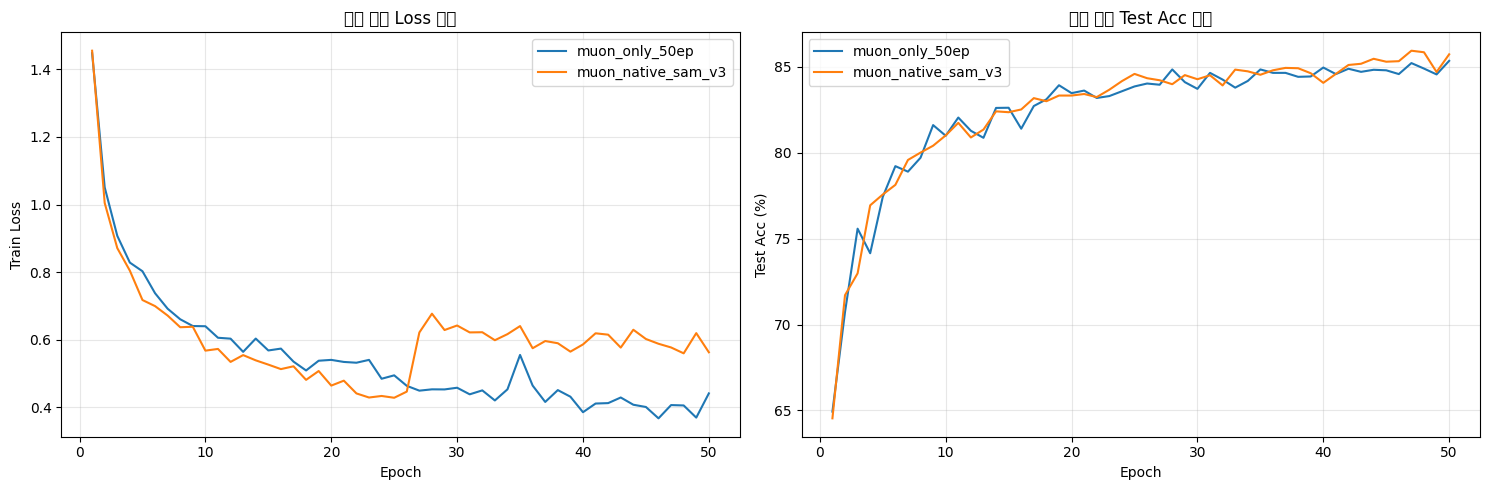

In [ ]:
import glob

def load_all_runs(save_dir):
    """MyDrive에 저장된 모든 실행 CSV를 통합"""
    csv_files = glob.glob(os.path.join(save_dir, 'runs_*.csv'))
    dfs = [pd.read_csv(f) for f in csv_files]
    return pd.concat(dfs, ignore_index=True).drop_duplicates(subset=['run_name', 'epoch'])

def plot_all_runs_comparison(df, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for name in df['run_name'].unique():
        d = df[df['run_name'] == name]
        axes[0].plot(d['epoch'], d['train_loss'], label=name)
        axes[1].plot(d['epoch'], d['test_acc'], label=name)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train Loss'); axes[0].set_title('전체 실행 Loss 비교')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Acc (%)'); axes[1].set_title('전체 실행 Test Acc 비교')
    for ax in axes: ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

df_history = load_all_runs(save_dir)
plot_all_runs_comparison(df_history, save_path=os.path.join(save_dir, 'all_runs_comparison.png'))

📐 [실험 A: 순수 Muon] 손실 지형 계산 중...
  ...50/225 지점 계산 완료
  ...100/225 지점 계산 완료
  ...150/225 지점 계산 완료
  ...200/225 지점 계산 완료


/tmp/ipykernel_1563/3603650237.py:74: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/3603650237.py:74: UserWarning: Glyph 54693 (\N{HANGUL SYLLABLE HYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/3603650237.py:74: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/3603650237.py:74: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/3603650237.py:74: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/3603650237.py:74: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1563/3603650237.py:74: UserWarning: Glyph 46321 (\N{HANGUL SYLLABLE DEUNG}) missing from font(s) DejaVu Sans.
  plt.t

✅ 저장: /content/drive/MyDrive/Colab_Data/hybrid_experiments/muon_only_50ep_landscape.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54693 (\N{HANGUL SYLLABLE HYANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

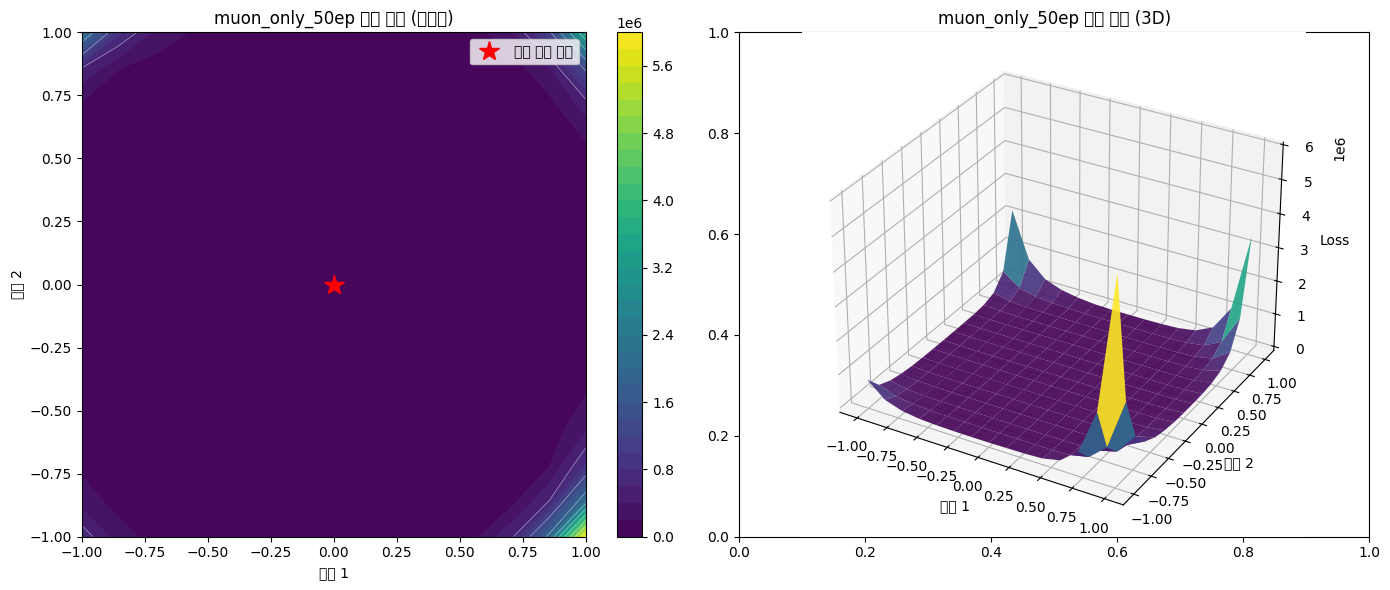


📐 [실험 B: Muon-native SAM] 손실 지형 계산 중...
  ...50/225 지점 계산 완료
  ...100/225 지점 계산 완료
  ...150/225 지점 계산 완료
  ...200/225 지점 계산 완료
✅ 저장: /content/drive/MyDrive/Colab_Data/hybrid_experiments/muon_native_sam_v3_landscape.png


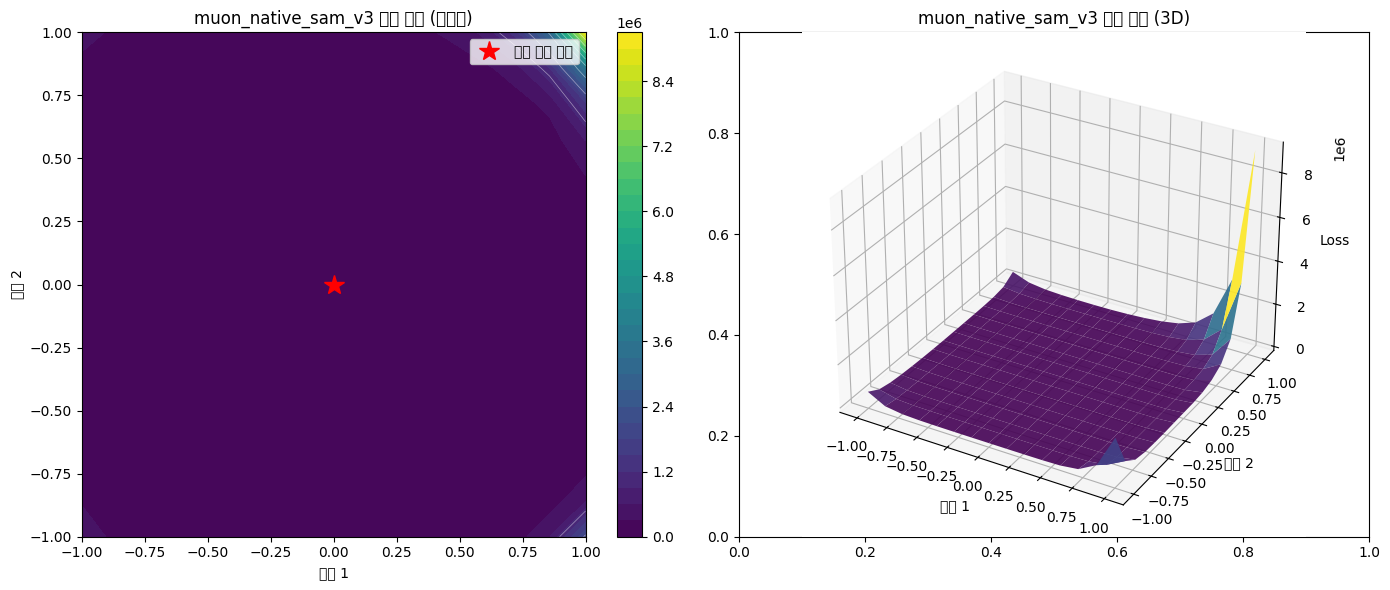

In [ ]:
print("📐 [실험 A: 순수 Muon] 손실 지형 계산 중...")
alphas_A, betas_A, grid_A = compute_loss_landscape(
    model_A, criterion, train_loader, device, n_points=15, span=1.0, n_batches=3)
plot_loss_landscape(alphas_A, betas_A, grid_A, title=f"{RUN_NAME_A} 최종 지점",
                     save_path=os.path.join(save_dir, f'{RUN_NAME_A}_landscape.png'))

print("\n📐 [실험 B: Muon-native SAM] 손실 지형 계산 중...")
alphas_B, betas_B, grid_B = compute_loss_landscape(
    model_B, criterion, train_loader, device, n_points=15, span=1.0, n_batches=3)
plot_loss_landscape(alphas_B, betas_B, grid_B, title=f"{RUN_NAME_B} 최종 지점",
                     save_path=os.path.join(save_dir, f'{RUN_NAME_B}_landscape.png'))